


# Vamos encher o carrinho!

# Introdução

O Instacart é uma plataforma de entrega de supermercado onde os clientes podem fazer um pedido no supermercado e depois receber sua compra, semelhante ao funcionamento do Uber Eats e do iFood. O conjunto de dados que fornecemos foi modificado a partir do original. Reduzimos o tamanho dele para que seus cálculos sejam executados mais rapidamente e incluímos valores ausentes e duplicados. Também tivemos o cuidado de preservar as distribuições dos dados originais quando fizemos as alterações.

Você precisa completar três etapas. Para cada uma delas, escreva uma breve introdução descrevendo como você pretende concluir a etapa e justifique suas decisões em parágrafos explicativos a medida que você avança na solução. Escreva também uma conclusão para resumir suas conclusões e escolhas.



## Dicionário de dados

Há cinco tabelas no conjunto de dados, e você vai precisar usar todas elas para pré-processar seus dados e fazer AED. Abaixo está um dicionário que lista as colunas de cada tabela e descreve os dados contidos nelas.

- `instacart_orders.csv`: cada linha corresponde a um pedido no aplicativo da Instacart
    - `'order_id'`: é o número que identifica cada pedido de forma exclusiva
    - `'user_id'`: é o número de identificação exclusivo da conta de cada cliente
    - `'order_number'`: é o número de vezes que o cliente fez um pedido
    - `'order_dow'`: é o dia da semana em que o pedido foi feito (0 é domingo)
    - `'order_hour_of_day'`: é a hora do dia em que o pedido foi feito
    - `'days_since_prior_order'`: é o número de dias desde que o cliente fez seu pedido anterior




- `products.csv`: cada linha corresponde a um produto exclusivo que os clientes podem comprar
    - `'product_id'`: é o número de identificação unívoco de cada produto
    - `'product_name'`: é o nome do produto
    - `'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    - `'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado




-	`order_products.csv`: cada linha corresponde a um item incluído em um pedido
    -	`'order_id'`: é o número que identifica cada pedido de forma exclusiva
    -	`'product_id'`: é o número de identificação exclusivo de cada produto
    -	`'add_to_cart_order'`: é a ordem sequencial em que cada item foi colocado no carrinho
    -	`'reordered'`: 0 se o cliente nunca comprou o produto antes, 1 se já o comprou




-	`aisles.csv`
    -	`'aisle_id'`: é o número de identificação exclusivo de cada categoria de corredor do supermercado
    -	`'aisle'`: é o nome do corredor



-	`departments.csv`
    -	`'department_id'`: é o número de identificação exclusivo de cada categoria de departamento do supermercado
    -	`'department'`: é o nome do departamento


# Etapa 1. Visão geral dos dados

Leia os arquivos de dados (/datasets/instacart_orders.csv, /datasets/products.csv, /datasets/aisles.csv, /datasets/departments.csv e /datasets/order_products.csv) com `pd.read_csv()` usando os parâmetros apropriados para fazer isso corretamente. Verifique as informações para cada DataFrame criado.


## Plano de solução

Escreva aqui seu plano para a Etapa 2. Visão geral dos dados


In [143]:
import pandas as pd 
from matplotlib import pyplot as plt #Importe as bibliotecas

In [144]:
instacart=pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products=pd.read_csv('/datasets/products.csv', sep=';')
aisles=pd.read_csv('/datasets/aisles.csv', sep=';')
departments=pd.read_csv('/datasets/departments.csv', sep=';')
order_products=pd.read_csv('/datasets/order_products.csv', sep=';')# leia os conjuntos de dados em DataFrames

In [145]:
print(instacart.info())# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None


In [146]:
print(products.info())# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None


In [147]:
print(aisles.info())# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None


In [148]:
print(departments.info())# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None


In [149]:
print(order_products.info(show_counts=True))# imprima as informações sobre o DataFrame

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None


## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 1. Visão geral dos dados
Depois de analisar os 5 conjuntos de dados pudemos identificar que existem numeros nulos em: instacard -> days_since_prior_order,
                                                                                             products -> product_name e
                                                                                             orde_products -> add_to_cart_order.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


- Os dados foram carregados corretamente.

- Conclusões foram apresentadas

# Etapa 2. Preparação de dados

Faça o pré-processamento dos dados da seguinte maneira:

-	Verifique e corrija os tipos de dados (por exemplo, certifique-se de que as colunas de ID sejam números inteiros)
-	Identifique e preencha valores ausentes
-	Identifique e remova valores duplicados

Certifique-se de explicar que tipos de valores ausentes e duplicados você encontrou, como você os preencheu ou removeu, por que escolheu esses métodos e por que você acha que esses valores ausentes e duplicados estavam presentes no conjunto de dados.

## Plano de solução

Escreva aqui seu plano para a Etapa 2. Preparação de dados

## Encontre e remova valores duplicados (e descreva por que você está fazendo suas escolhas)

### DataFrame `instacart_orders`

In [150]:
instacart.duplicated().sum()# Verificar se há pedidos duplicados

15

Há linhas duplicadas? Se sim, o que elas têm em comum?
Sim e todos esses pedidos foram feito na quarta as 2 horas da manha.

In [151]:

# Com base nas suas conclusões,
pedidos_2h_quarta = instacart.query("order_hour_of_day == 2 and order_dow == 3")
print(pedidos_2h_quarta)# verifique todos os pedidos feitos às 2h da manhã nas quartas-feiras


        order_id  user_id  order_number  order_dow  order_hour_of_day  \
4838     2766110   162084            41          3                  2   
5156     2190225   138285            18          3                  2   
15506     553049    58599            13          3                  2   
18420     382357   120200            19          3                  2   
24691     690242    77357             2          3                  2   
...          ...      ...           ...        ...                ...   
457013   3384021    14881             6          3                  2   
458816    910166   164782            18          3                  2   
459635   1680532   106435             6          3                  2   
468324    222962    54979            59          3                  2   
477526   2592344    46860            38          3                  2   

        days_since_prior_order  
4838                      16.0  
5156                      11.0  
15506                   

O que esse resultado quer dizer?
Com base nas minhas conclusões, pude observar que tem 2 clientes com um volume considerável de pedidos e uma frequência de 3 dias desde o último pedido. Vou analisar se eles podem ter alguma relação com os 15 valores duplicados que encontramos.

In [152]:
instacart=instacart.drop_duplicates()# Remova pedidos duplicados

In [153]:
instacart.duplicated().sum()# Verifique as linhas duplicadas mais uma vez

0

In [154]:
duplicadas = instacart[instacart.duplicated()]
print(duplicadas)#verifique novamente apenas os IDs de pedidos duplicados

Empty DataFrame
Columns: [order_id, user_id, order_number, order_dow, order_hour_of_day, days_since_prior_order]
Index: []


Descreva brevemente suas conclusões e o que você fez com elas.
Após a análise dos dados do Instacart, foram identificados 15 pedidos duplicados no dataset principal. Essas duplicatas foram removidas para evitar distorções nas análises a seguir. O dataset agora contém 478.952 pedidos únicos.

### DataFrame `products`

In [155]:
products.duplicated().sum()# Verifique se há linhas completamente duplicadas

0

In [156]:
products['product_id'].duplicated().sum()# Verifique apenas IDs dos produtos duplicados

0

In [157]:
products['product_name'].str.lower().duplicated().sum()# Verifique apenas nomes de produtos duplicados (converta os nomes para minúsculas para uma comparação melhor)

1361

In [158]:
products['product_name'].duplicated().sum()# Verifique os nomes de produtos duplicados que não estão faltando

1257

Descreva brevemente suas conclusões e o que você fez com elas.
Para começar a analise, verifiquei se existia linha completamente duplicadas, não existe, depois verifiquei se havia duplicadas na coluna product_id, o que tambem não existe. Depois converti os nomes de product_name para minúsculas e pude perceber que existem 1361 duplicações entre nomes iguais, maiúsculos e minúsculos e por fim verifiquei que existem 1257 duplicados sem levar em consideração minúsculos ou maiúsculos, o que nos fazer perceber que 104 dessas duplicatas são maiúsculos e minúsculos. 

### DataFrame `departments`

In [159]:
departments.duplicated().sum()# Verifique se há linhas completamente duplicadas

0

In [160]:
departments['department_id'].duplicated().sum()# Verifique apenas IDs duplicados de departamentos

0

Descreva brevemente suas conclusões e o que você fez com elas.
Depois de analisar o dataframe departments, pude constatar que não existe linhas completas duplicada e tão pouco ids.

### DataFrame `aisles`

In [161]:
aisles.duplicated().sum()# Verifique se há linhas completamente duplicadas

0

In [162]:
aisles['aisle_id'].duplicated().sum()# Verifique apenas IDs duplicados de corredores

0

Descreva brevemente suas conclusões e o que você fez com elas.
Depois de analisar o dataframe aisles, pude constatar que não existe linhas completas duplicada e tão pouco de corredores.

### DataFrame `order_products`

In [163]:
order_products.duplicated().sum()# Verifique se há linhas completamente duplicadas

0

In [164]:
order_products[['order_id','product_id']].duplicated().sum()# Verifique mais uma vez se há outros casos complicados de duplicados

0

Descreva brevemente suas conclusões e o que você fez com elas.
Depois de analisar o dataframe order_products, pude constatar que não existe linhas completas duplicada, e também não há valores duplicados mais complicados como em order_id e product_id juntos.

## Encontre e remova valores ausentes


Ao processarmos valores duplicados, observamos que também temos valores ausentes que precisamos investigar nas seguintes colunas:

*	A coluna `'product_name'` da tabela products.
*	A coluna `'days_since_prior_order'` da tabela orders.
*	A coluna `'add_to_cart_order'` da tabela order_products.


### DataFrame `products`

In [165]:
products['product_name'].isna().sum()# Encontre valores ausentes na coluna 'product_name'

1258

Descreva brevemente suas conclusões. Pude concluir que tem 1258 valores ausentes na coluna product_name

In [166]:
products.query("aisle_id == 100").isna().sum()# Todos os nomes de produtos ausentes estão associados com o corredor de ID 100?

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

Descreva brevemente suas conclusões.Aqui podemos notar que todos os nomes de produtos ausentes, estão associados ao corredor 100.

In [167]:
products.query("department_id == 21").isna().sum()# Todos os nomes de produtos ausentes estão associados com o departamento de ID 21?

product_id          0
product_name     1258
aisle_id            0
department_id       0
dtype: int64

Descreva brevemente suas conclusões.Já aqui conseguimos confirmar que junto com o corredor 100 o departamente 21 também está associado os nomes de produtos ausentes .

In [168]:
departments.query("department_id == 21") , aisles.query("aisle_id == 100")
# Use as tabelas department e aisle para verificar os dados do corredor com ID 100 e do departamento com ID 21.

(    department_id department
 20             21    missing,
     aisle_id    aisle
 99       100  missing)

Descreva brevemente suas conclusões. Agora podemos confirmar que os dados no departamento 21 e corredor 100 estão ausentes, isso pode ter sido gerado por alguma falha na hora de cadastrar os produtos.

In [169]:
products['product_name']=products['product_name'].fillna('Unknown')
products.info()# Preencha nomes de produtos ausentes com 'Unknown'

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   49694 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB


Descreva brevemente suas conclusões e o que você fez com elas.Depois de localizar e entender que os valores ausentes podem ter sido uma falha no momento do cadastro por se localizar todos no mesmo departamento e corredor, alterar os valores.Acrescentei também mais uma info para confirmar que não existem mais valores nulos.

### DataFrame `orders`

In [170]:
instacart.isna().sum()# Encontre os valores ausentes

order_id                      0
user_id                       0
order_number                  0
order_dow                     0
order_hour_of_day             0
days_since_prior_order    28817
dtype: int64

In [171]:
instacart.query("order_number >1").isna().sum()# Há valores ausentes para os clientes que não estão fazendo o primeiro pedido?

order_id                  0
user_id                   0
order_number              0
order_dow                 0
order_hour_of_day         0
days_since_prior_order    0
dtype: int64

Descreva brevemente suas conclusões e o que você fez com elas.Com essas analises, pude notar que os valores ausentes/nulos que aparecem em days_since_prior_order se tratam apenas dos novos clientes que estão realizando seu primeiro pedido. 

### DataFrame `order_products`

In [172]:
order_products['add_to_cart_order'].isna().sum()# Encontre os valores ausentes

836

In [173]:
order_products['add_to_cart_order'].min() , order_products['add_to_cart_order'].max()# Quais são os valores mínimo e máximo dessa coluna?

(1.0, 64.0)

Descreva brevemente suas conclusões.Pude notar que temos 836 linhas ausentes na coluna add_to_cart_order, o que precisamos investigar mais a fundo já que se trata de item colocados no carrinho de compras(o que o numero deveria pelo menos ser 1), e também sabemos que o numero de itens minímo é 1 e o maximo 64. 

In [174]:
ids_ausentes=order_products[order_products['add_to_cart_order'].isna()]['order_id'].unique()
print(ids_ausentes)# Salve todos os IDs dos pedidos com pelo menos um valor ausente em 'add_to_cart_order'

[2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093  129627  293169 2849370 1386261 3308010  903110 2136777 3347453
 1888628  165801 2094761 1038146 2997021  813364 2256933  171934 2409109
 1730767 1169835  733526  404157 3125735  747668 1800005 1961723  871281
  388234 1648217 1477139  102236 1021563 1832957 2721963  678116 1220886
 1673227 2999801 1633337 2470674 2625444 1677118 2479011 3383594 1183255
 1713430 2652650 1598369 1916118  854647 1302315  888470  180546 2621907
 1308785 2729254    9310 2170451 2979697 1625713 1529171]


In [175]:
pedidos_com_ausentes = order_products[order_products['order_id'].isin(ids_ausentes)]# Todos os pedidos com valores ausentes contêm mais de 64 produtos?
contagem_produtos = pedidos_com_ausentes.groupby('order_id')['product_id'].count() #Agrupe os pedidos com dados ausentes por ID de pedido
contagem_produtos.min()>=64# Conte o número de 'product_id' em cada pedido e verifique o valor mínimo da contagem

True

Descreva brevemente suas conclusões. Depois de longas analises, pude observar que o sistema tem uma falha com pedidos grandes (superiores a 64 itens).E por isso existem 836 valores ausentes na coluna add_to_cart_order.

In [176]:
order_products['add_to_cart_order']=order_products['add_to_cart_order'].fillna(999).astype(int)# Substitua valores ausentes na coluna 'add_to_cart_order' por 999 e converta a coluna para o tipo integer

Descreva brevemente suas conclusões e o que você fez com elas. Preenchemos as colunas vazias de add_to_cart_order com o numero 999 para que durante a analise possamos saber que esse item foi adicionado após o item de numero 64 (só não sabemos a ordem que ele se encontra). e depois passamos a coluna todas para numero inteiros.

## Conclusões

Escreva aqui suas conclusões intermediárias da Etapa 2. Preparação de dados: Durante o tratamento de dados, pude identificar e tratar valores ausentes; identificar e remover duplicatas e também pude verificar valores que pareciam ser nulos, mas se tratavam apenas do primeiros pedidos de clientes novos.  Agora o dataset esta limpo e parado para as próximas etapas de analise.

<div class="alert alert-block alert-success">

<b>Comentário: </b> <a class="tocSkip"></a>


- Boas estratégias para processamento de dados.

# Etapa 3. Análise de dados

Quando os dados estiverem processados ​​e prontos, execute a seguinte análise:

# [A] Fácil (é necessário concluir tudo para passar)

1.	Verifique se os valores nas colunas `'order_hour_of_day'` e `'order_dow'` na tabela `orders` fazem sentido (ou seja, os valores da coluna  `'order_hour_of_day'` variam de 0 a 23 e os da `'order_dow'` variam de 0 a 6).
2.	Crie um gráfico que mostre quantas pessoas fazem pedidos a cada hora do dia.
3.	Crie um gráfico que mostre em que dia da semana as pessoas fazem compras.
4.	Crie um gráfico que mostre quanto tempo as pessoas esperam até fazer seu próximo pedido e comente sobre os valores mínimo e máximo.


### [A1] Verifique se os valores fazem sentido

In [177]:
instacart.query("order_hour_of_day >= 0 and order_hour_of_day <=23")

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


In [178]:
instacart.query("order_dow >=0 and order_dow <= 6")

,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,1515936,183418,11,6,13,30.0
1,1690866,163593,5,5,12,9.0
2,1454967,39980,4,5,19,2.0
3,1768857,82516,56,0,20,10.0
4,3007858,196724,2,4,12,17.0
...,...,...,...,...,...,...
478962,3210681,5617,5,1,14,7.0
478963,3270802,112087,2,3,13,6.0
478964,885349,82944,16,2,11,6.0
478965,216274,4391,3,3,8,8.0


Escreva suas conclusões aqui. Podemos verificar que tanto a coluna de dias quanto a de horas estão corretas em suas medidas. As horas vão de  (0 a 23  horas) e os dias de (0 começa no domingo e 6 termina no sabádo).

### [A2] Quantas pessoas fazem pedidos a cada hora do dia?

<AxesSubplot:title={'center':'Quantidade de Pessoas Que Fizeram Pedido Por Hora'}, xlabel='Hora', ylabel='Pedidos'>

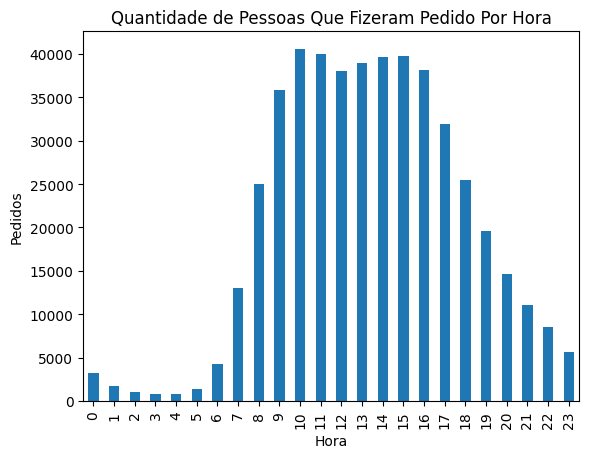

In [179]:

pedidos_por_hora=instacart['order_hour_of_day'].value_counts().sort_index()
pedidos_por_hora.plot.bar(ylabel= "Pedidos",
                         xlabel="Hora",
                         title="Quantidade de Pessoas Que Fizeram Pedido Por Hora")


Escreva suas conclusões aqui. Com esse gráfico pude notar que o maior pico de pessoas realizando pedidos é entre as 10 da manha e 16horas da tarde.

### [A3] Em que dia da semana as pessoas compram produtos alimentícios?

<AxesSubplot:title={'center':'Compra de Produtos Alimentícios por Dia da Semana'}, xlabel='Dias da Semana(0=domingo)', ylabel='Pedidos'>

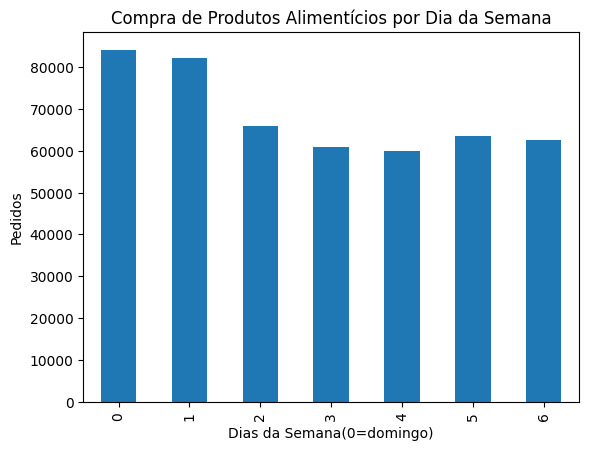

In [180]:



dias_da_semana=instacart['order_dow'].value_counts().sort_index()
dias_da_semana.plot.bar(ylabel="Pedidos",
                       xlabel="Dias da Semana(0=domingo)",
                       title="Compra de Produtos Alimentícios por Dia da Semana")




<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>
    
Sugestão alternativa de como visualizar o gráfico com os dias da semana nomeados: 

```python
import pandas as pd
import matplotlib.pyplot as plt

orders = pd.read_csv("/datasets/instacart_orders.csv", sep=';')
order_products = pd.read_csv("/datasets/order_products.csv", sep=';')
products = pd.read_csv("/datasets/products.csv", sep=';')
aisles = pd.read_csv("/datasets/aisles.csv", sep=';')
departments = pd.read_csv("/datasets/departments.csv", sep=';')

dados = (
    order_products
    .merge(orders, on='order_id')
    .merge(products, on='product_id')
    .merge(aisles, on='aisle_id')
    .merge(departments, on='department_id')
)

produtos_alimenticios = dados[dados['aisle'].str.contains('food', case=False, na=False)]

compras_por_dia = produtos_alimenticios['order_dow'].value_counts().sort_index()

dias_semana = ['Domingo', 'Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado']
compras_por_dia.index = [dias_semana[i] for i in compras_por_dia.index]

print("🗓️ Compras de produtos alimentícios por dia da semana:")
print(compras_por_dia)

plt.figure(figsize=(8,5))
plt.bar(compras_por_dia.index, compras_por_dia.values, color='seagreen', edgecolor='black')
plt.title("Compras de produtos alimentícios por dia da semana", fontsize=14, fontweight='bold')
plt.xlabel("Dia da semana")
plt.ylabel("Número de pedidos")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
```

Escreva suas conclusões aqui. Neste grafíco podemos notar que os dias que as pessoas mais realizam compra de produtos alimentícios é domingo e segunda. 

### [A4] Quanto tempo as pessoas esperam até fazer outro pedido?

Escreva suas conclusões aqui.  Aqui, podemos notar que grande maioria das pessoa demoram certa de 30 dias para realizar o próximo pedido, mas também não podemos deixar de notar, que o intervalo de 1 á 7 dias do ultimo pedido são bem elevados.

<AxesSubplot:title={'center':'Intervalo de Tempo entre Pedidos '}, xlabel='Dias até o proximo pedido', ylabel='Pedidos'>

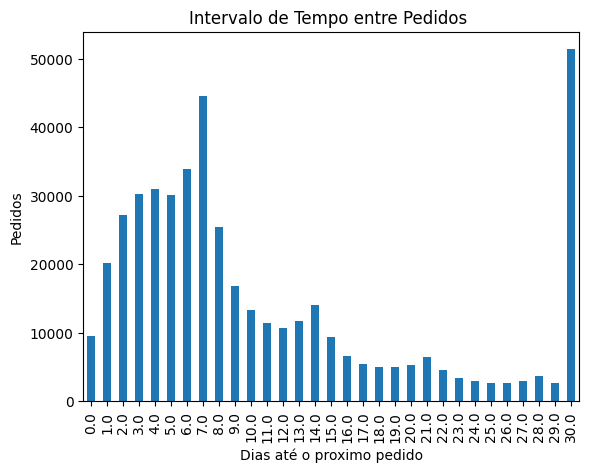

In [181]:

outro_pedido=instacart['days_since_prior_order'].value_counts().sort_index()
outro_pedido.plot.bar(ylabel="Pedidos",
                     xlabel="Dias até o proximo pedido",
                     title="Intervalo de Tempo entre Pedidos ")



# [B] Médio (é necessário concluir tudo para passar)

1.	Há alguma diferença nas distribuições de `'order_hour_of_day'` nas quartas e sábados? Construa gráficos de barras para ambos os dias no mesmo gráfico e descreva as diferenças que você notou.
2.	Construa um gráfico de distribuição para o número de pedidos que os clientes fazem (ou seja, quantos clientes fizeram apenas 1 pedido, quantos fizeram apenas 2, quantos apenas 3, etc.)
3.	Quais são os 20 produtos comprados com mais frequência? Exiba os IDs e nomes.


### [B1] Diferenças nas quartas e sábados em `'order_hour_of_day'`. Crie gráficos de barras para ambos os dias e descreva as diferenças.

In [182]:
quarta=instacart.query("order_dow == 3")['order_hour_of_day']

In [183]:
sabado=instacart.query("order_dow == 6")['order_hour_of_day']

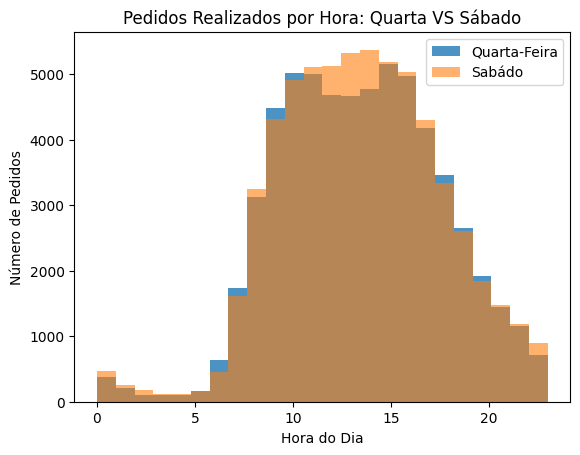

In [184]:
plt.hist(quarta,bins=24,alpha=0.8,label="Quarta-Feira")
plt.hist(sabado,bins=24,alpha=0.6,label="Sabádo")
plt.xlabel('Hora do Dia')
plt.ylabel('Número de Pedidos')
plt.title('Pedidos Realizados por Hora: Quarta VS Sábado')
plt.legend()
plt.show()

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>

O gráfico está correto. Para mellhor legibilidade da diferença entre os dias, recomendo realizar o gráfico da seguinte maneira: 

```python
import matplotlib.pyplot as plt

# Define o tamanho da figura do gráfico (largura x altura)
plt.figure(figsize=(14, 8))

# Cria um intervalo de horas de 0 a 23
x = range(24)  # Horas de 0 a 23

# Define a largura das barras para permitir barras lado a lado
width = 0.35

# Cria as barras referentes à quarta-feira
# Reindex garante que todas as horas existam (0 a 23), preenchendo com 0 quando não houver pedidos
plt.bar(
    [i - width/2 for i in x],                 # Desloca as barras para a esquerda
    pedidos_quarta.reindex(x, fill_value=0),  # Dados de pedidos da quarta-feira
    width,
    label='Quarta-feira',
    alpha=0.8,
    color='blue'
)

# Cria as barras referentes ao sábado
plt.bar(
    [i + width/2 for i in x],                 # Desloca as barras para a direita
    pedidos_sabado.reindex(x, fill_value=0),  # Dados de pedidos do sábado
    width,
    label='Sábado',
    alpha=0.8,
    color='orange'
)

# Define o título do gráfico
plt.title('Comparação de Pedidos por Hora: Quarta vs Sábado')

# Define o rótulo do eixo X
plt.xlabel('Hora do Dia')

# Define o rótulo do eixo Y
plt.ylabel('Número de Pedidos')

# Define as marcações do eixo X (uma para cada hora)
plt.xticks(x)

# Exibe a legenda identificando cada conjunto de barras
plt.legend()

# Adiciona uma grade horizontal para facilitar a leitura dos valores
plt.grid(axis='y', alpha=0.3)

# Exibe o gráfico na tela
plt.show()

```

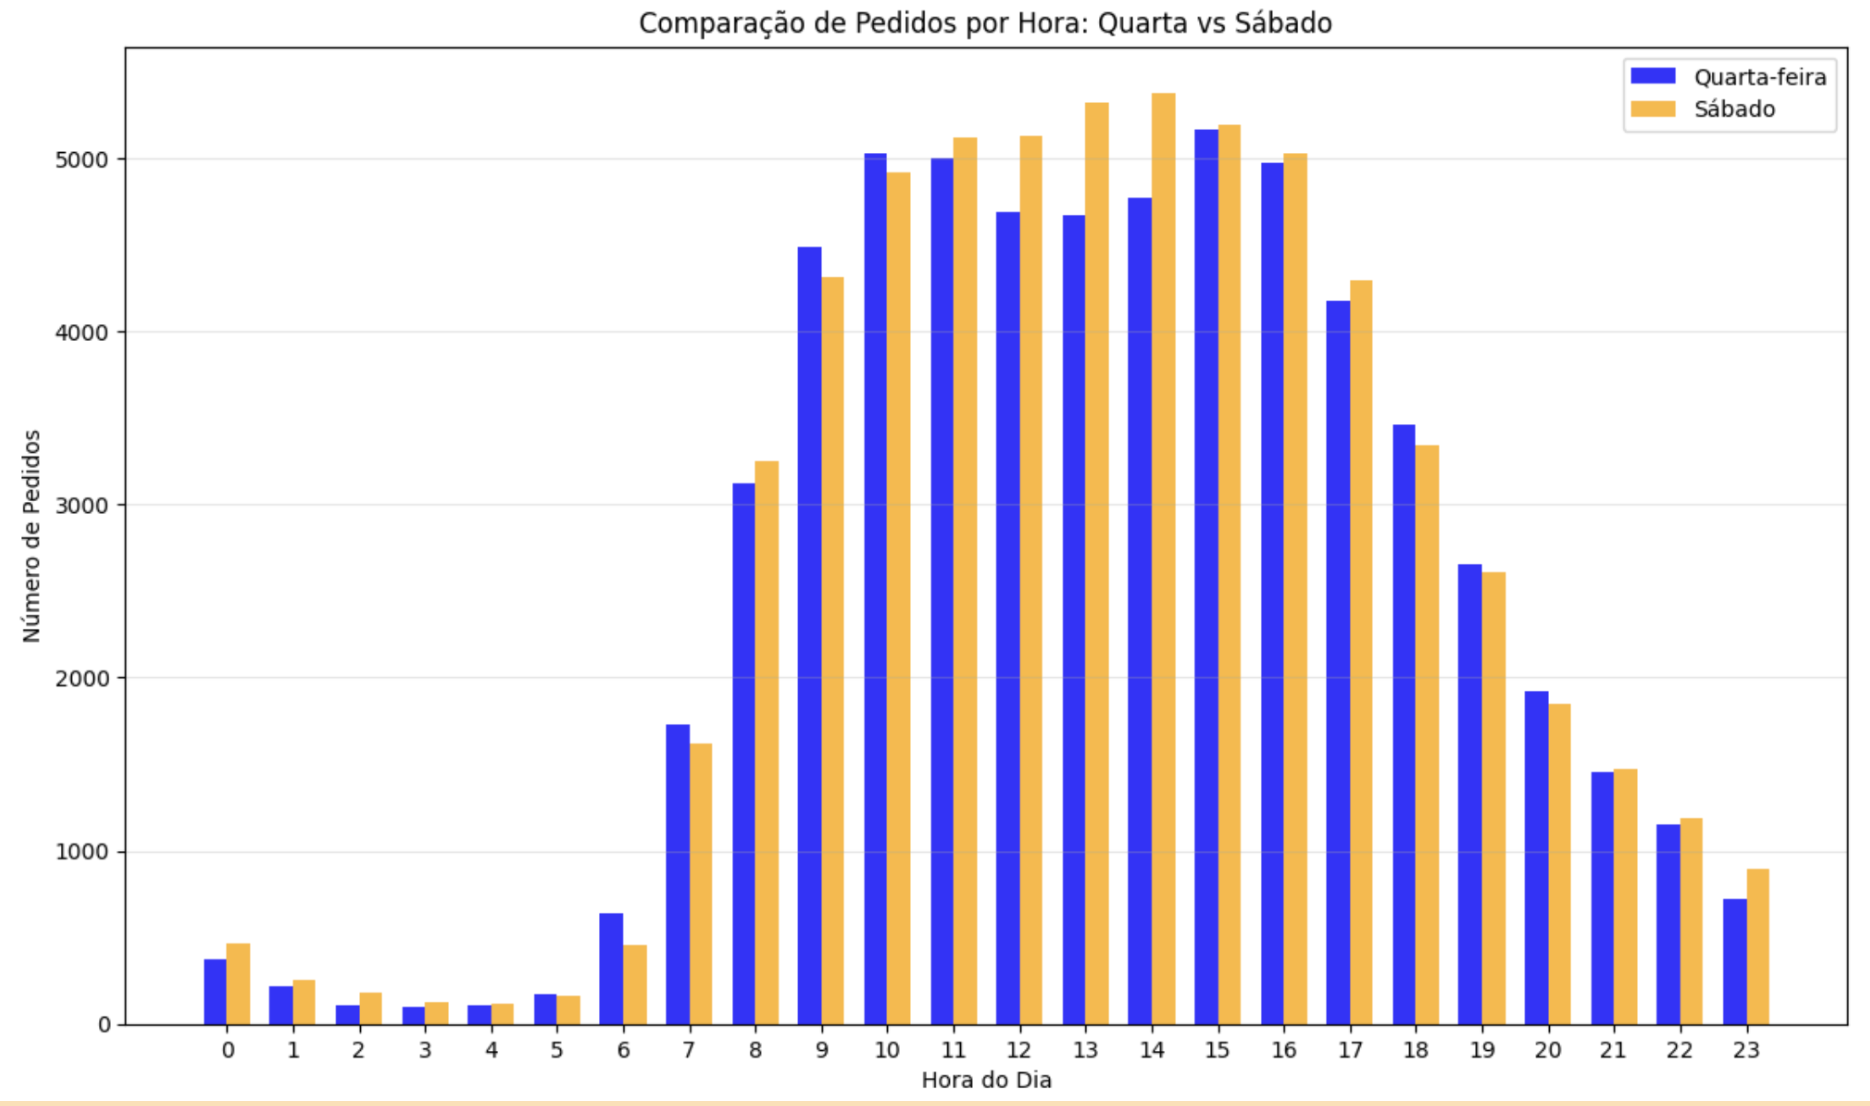

Escreva suas conclusões aqui. Com o gráfico podemos notar que quarta e sábado são bem igualitários em questão de pedidos ao decorrer do dia,  visto que sábado ganhou um destaque a mais no almoço em comparação a quarta. O que pode ser, por se tratar de final de semana.

### [B2] Qual é a distribuição do número de pedidos por cliente?

In [185]:
pedidos_por_cliente=instacart['order_number'].value_counts().sort_index()

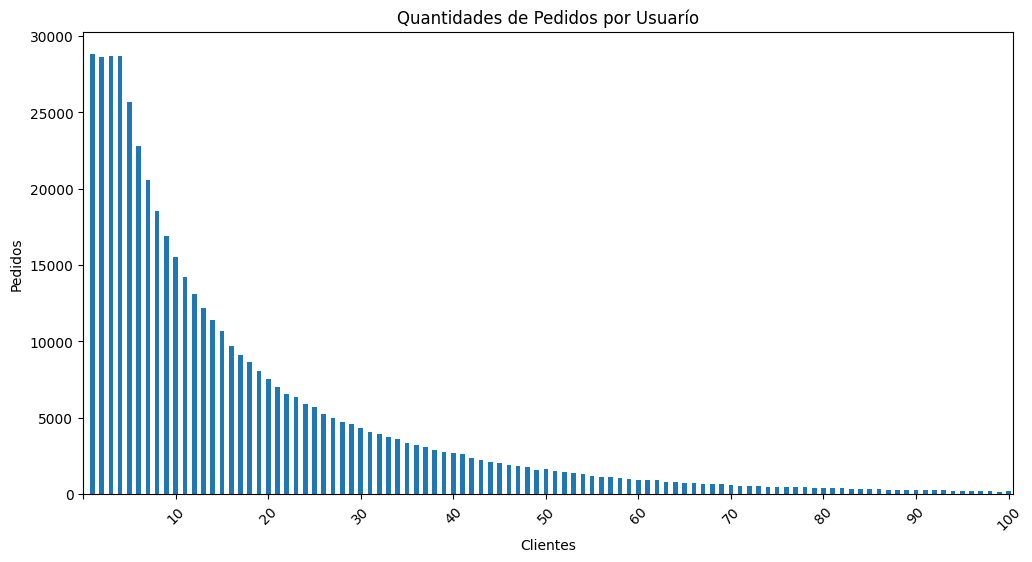

In [186]:
pedidos_por_cliente.plot.bar(ylabel='Pedidos',xlabel='Clientes', title="Quantidades de Pedidos por Usuarío",figsize=(12,6))
plt.xticks(rotation=45)
plt.xticks(range(-1,100,10))
plt.show()

Escreva suas conclusões aqui. Com esse gráfico podemos ver que tem muitos usúarios novos, mas que também temos muitos usúrios com mais de 30,40, 50 pedidos feitos.

### [B3] Quais são os 20 produtos mais populares? Exiba os IDs e nomes.

In [187]:
produtos_populares=order_products.groupby('product_id')['order_id'].count()
top_20_produtos=produtos_populares.sort_values(ascending=False).head(20)

In [188]:
top_20_produtos=top_20_produtos.reset_index()
top_20_produtos.merge(products,on='product_id',how='left')

,product_id,order_id,product_name,aisle_id,department_id
0,24852,66050,Banana,24,4
1,13176,53297,Bag of Organic Bananas,24,4
2,21137,37039,Organic Strawberries,24,4
3,21903,33971,Organic Baby Spinach,123,4
4,47209,29773,Organic Hass Avocado,24,4
5,47766,24689,Organic Avocado,24,4
6,47626,21495,Large Lemon,24,4
7,16797,20018,Strawberries,24,4
8,26209,19690,Limes,24,4
9,27845,19600,Organic Whole Milk,84,16


Escreva suas conclusões aqui. Agora podemos ver que o top 20 produtos são frutas e produtos orgânicos.

# [C] Difícil (é necessário concluir pelo menos duas perguntas para passar)

1.	Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?
2.	Quais são os 20 principais itens incluídos mais frequentemente em pedidos repetidos? Exiba os IDs e nomes.
3.	Para cada produto, qual parcela de seus pedidos são repetidos? Crie uma tabela com colunas de ID e nome do produto e a proporção de pedidos repetidos.
4.	Para cada cliente, qual proporção de todos os seus pedidos são repetidos?
5.	Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros? Exiba o ID do produto, nome e o número de vezes que ele foi o primeiro a ser adicionado a um carrinho.


### [C1] Quantos itens as pessoas normalmente compram em um pedido? Como fica a distribuição?

In [189]:
itens_por_pedido=order_products.groupby('order_id')['add_to_cart_order'].count()

In [190]:
contagem_itens_por_pedido=itens_por_pedido.value_counts().sort_index(ascending=True)

In [191]:
itens_por_pedido.mean()

10.098983215049127

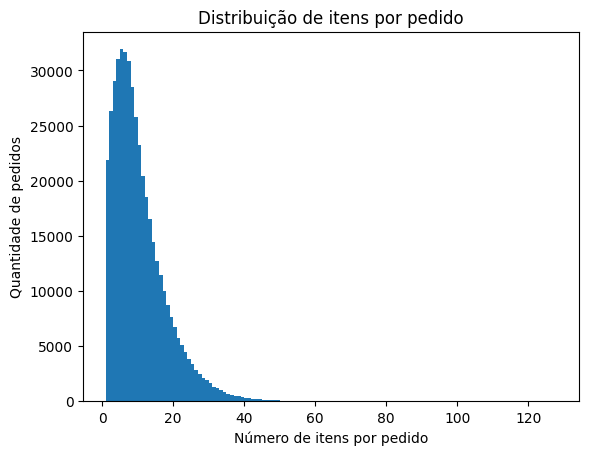

In [192]:
itens_por_pedido.mean()
plt.hist(itens_por_pedido,bins=range(1, itens_por_pedido.max()+2))
plt.title("Distribuição de itens por pedido")
plt.ylabel("Quantidade de pedidos")
plt.xlabel("Número de itens por pedido")
plt.show()

Escreva suas conclusões aqui. Como podemos ver no gráfico, a média de pedidos e 10 itens, mas é indiscutível que a grande parte dos pedidos tem entre 1 e 20 itens.

### [C2] Quais são os 20 principais itens incluídos com mais frequência em pedidos repetidos? Exiba os IDs e nomes.

In [193]:
produtos_repetidos=order_products.query("reordered == 1")

In [194]:
pedidos_freq=produtos_repetidos.groupby('product_id')['order_id'].count()

In [195]:
top_20_repetidos=pedidos_freq.sort_values(ascending=False).head(20).reset_index()

In [196]:
top_20_repetidos.merge(products,on="product_id",how='left')

,product_id,order_id,product_name,aisle_id,department_id
0,24852,55763,Banana,24,4
1,13176,44450,Bag of Organic Bananas,24,4
2,21137,28639,Organic Strawberries,24,4
3,21903,26233,Organic Baby Spinach,123,4
4,47209,23629,Organic Hass Avocado,24,4
5,47766,18743,Organic Avocado,24,4
6,27845,16251,Organic Whole Milk,84,16
7,47626,15044,Large Lemon,24,4
8,27966,14748,Organic Raspberries,123,4
9,16797,13945,Strawberries,24,4


Escreva suas conclusões aqui. Agora conseguimos ver a lista dos top 20 produtos repetidos, e  produtos organicos seguem em alta.

### [C3] Para cada produto, qual parcela de todos os pedidos dele são repetidos?

In [197]:
total_compras = order_products.groupby('product_id')['order_id'].count()

In [198]:
recompras = order_products.query("reordered ==1").groupby('product_id')['order_id'].count()

In [199]:
parcela_pedidos_repetidos = recompras / total_compras
tabela_proporcoes = parcela_pedidos_repetidos.reset_index()
tabela_proporcoes.columns = ['product_id', 'proporcao_repetidos']
tabela_final = tabela_proporcoes.merge(products[['product_id', 'product_name']], 
                                       on='product_id', 
                                       how='left')
tabela_final['proporcao_repetidos'] = tabela_final['proporcao_repetidos'].fillna(0)
print(tabela_final.head(10))

   product_id  proporcao_repetidos  \
0           1             0.564286   
1           2             0.000000   
2           3             0.738095   
3           4             0.510204   
4           7             0.500000   
5           8             0.315789   
6           9             0.761905   
7          10             0.448071   
8          11             0.625000   
9          12             0.390244   

                                        product_name  
0                         Chocolate Sandwich Cookies  
1                                   All-Seasons Salt  
2               Robust Golden Unsweetened Oolong Tea  
3  Smart Ones Classic Favorites Mini Rigatoni Wit...  
4                     Pure Coconut Water With Orange  
5                  Cut Russet Potatoes Steam N' Mash  
6                  Light Strawberry Blueberry Yogurt  
7     Sparkling Orange Juice & Prickly Pear Beverage  
8                                  Peach Mango Juice  
9                         Choco

Escreva suas conclusões aqui.Podemos perceber que os itens com mais probabilidades de recompra e os queridinhos são os mais saudáveis, como já pudemos ver nas tabelas anteriores de top 20 e top 20 recompras.

### [C4] Para cada cliente, qual proporção de todos os seus pedidos são repetidos?

In [200]:
total_pedidos_clientes = instacart.groupby('user_id')['order_number'].count()
pedidos_repetidos = order_products.merge(instacart,on='order_id',how='left')

In [201]:
proporcao_por_cliente = pedidos_repetidos.groupby('user_id')['reordered'].mean()
print(proporcao_por_cliente.head(10))

user_id
2     0.038462
4     0.000000
5     0.666667
6     0.000000
7     0.928571
11    0.200000
12    0.250000
13    0.565217
14    0.360656
15    0.538462
Name: reordered, dtype: float64


Escreva suas conclusões aqui. Podemos notar que a maioria dos clientes, são bem fieis aos produtos que compram normalmente. Isso pode estar relacionado com os bons hábitos saudáveis . 

### [C5] Quais são os 20 principais itens que as pessoas colocam nos carrinhos antes de todos os outros?

<div class="alert alert-block alert-warning">
<b>Comentário: </b> <a class="tocSkip"></a>


Dica de como resolver: 

```python
# Filtrando apenas os itens que foram adicionados primeiro (posição 1)
first_items = df_order_products[df_order_products['add_to_cart_order'] == 1]

# Contando a frequência de cada produto
first_item_counts = first_items['product_id'].value_counts().head(20).reset_index()
first_item_counts.columns = ['product_id', 'first_added_count']

# Unindo com a tabela de produtos para obter os nomes
top_20_first = first_item_counts.merge(df_products[['product_id', 'product_name']], on='product_id')

print(top_20_first[['product_id', 'product_name', 'first_added_count']])
```

Escreva suas conclusões aqui

# Conclusão geral do projeto:

In [205]:
print("Ao longo do projeto, pudemos notar que a grande demanda das pessoas que utilizam o aplicativo, obtam por hábitos saudáveis, produtos orgânicos e são fieis aos produtos que consomem.") 

Ao longo do projeto, pudemos notar que a grande demanda das pessoas que utilizam o aplicativo, obtam por hábitos saudáveis, produtos orgânicos e são fieis aos produtos que consomem.


<div class="alert alert-block alert-success">
<b>Comentário: </b> <a class="tocSkip"></a>

Boa conclusão! Espero que tenha se divertido durante a realização do projeto :) 

</div>